# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

In [2]:
import pandas as pd
genes0607 = pd.read_csv('genes0607.csv')
genes0607

,Unnamed: 0,numero de caracteres,2 primeiros caracteres,quantos 'a' existem,presença de 'hu'
0,srs12b,6,sr,0,False
1,sag1,4,sa,1,False
2,gra1,4,gr,1,False
3,tuba1,5,tu,1,False
4,sag3,4,sa,1,False


## 01 – Descreva o racional da sua resposta:

R.: Inicio calculando o número de vezes que cada valor aparece na coluna (numero de caracteres, utilizando value_counts()), a partir disso utilizo map() para realizar essa contagem conforme a linha e adiciono ao dataframe em forma de coluna "frequencia". 

## 02 – Desenhe o fluxograma da resposta:

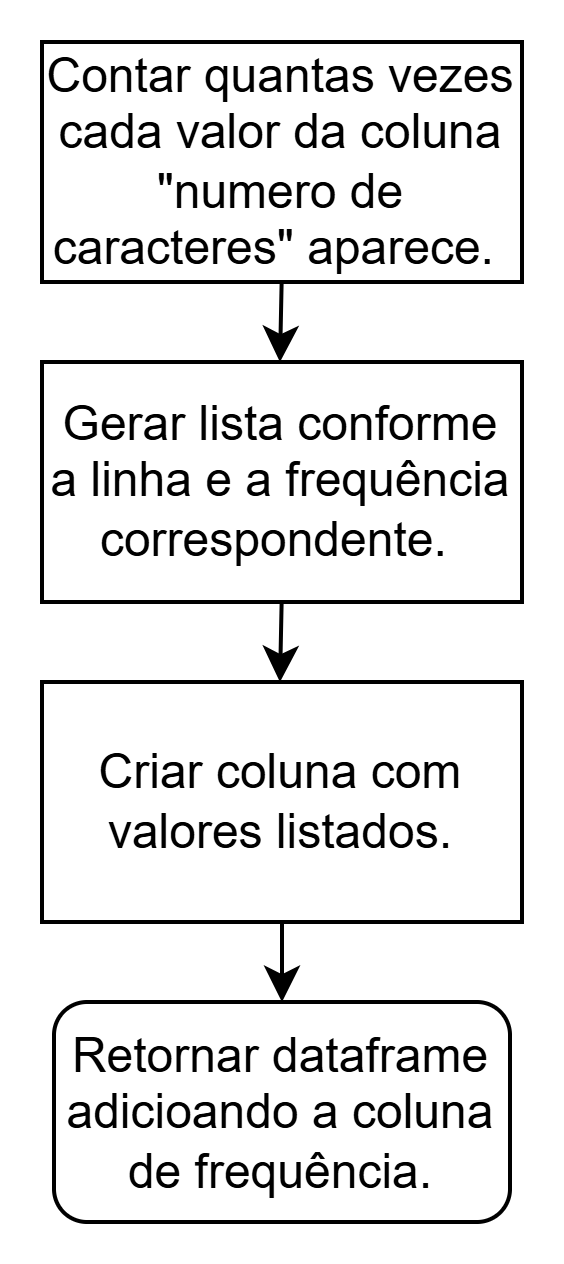

## 03 – Escreva o programa em Python:

In [3]:
genes0607["frequencia"] = genes0607["numero de caracteres"].map(
    genes0607["numero de caracteres"].value_counts()
)
genes0607

,Unnamed: 0,numero de caracteres,2 primeiros caracteres,quantos 'a' existem,presença de 'hu',frequencia
0,srs12b,6,sr,0,False,1
1,sag1,4,sa,1,False,3
2,gra1,4,gr,1,False,3
3,tuba1,5,tu,1,False,1
4,sag3,4,sa,1,False,3


<Axes: xlabel='numero de caracteres'>

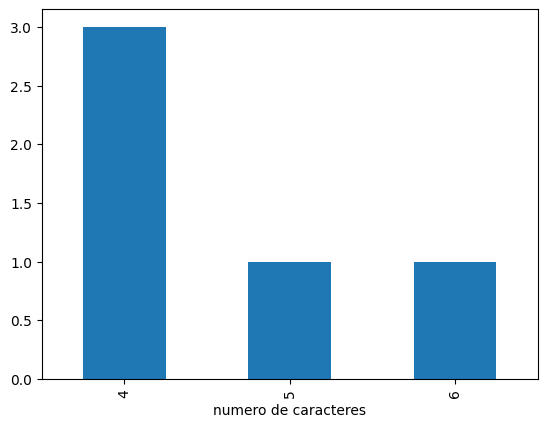

In [4]:
genes0607["numero de caracteres"].value_counts().sort_index().plot(kind="bar")

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

In [5]:
genes0607 = pd.read_csv('genes0607.csv')
genes0607

,Unnamed: 0,numero de caracteres,2 primeiros caracteres,quantos 'a' existem,presença de 'hu'
0,srs12b,6,sr,0,False
1,sag1,4,sa,1,False
2,gra1,4,gr,1,False
3,tuba1,5,tu,1,False
4,sag3,4,sa,1,False


## 04 – Descreva o racional da sua resposta:

R.: Construo o código agrupando os dados pelo número de caracteres e contando, para cada linha, quantas vezes aquele valor já apareceu até o momento na coluna, respeitando a ordem. Em seguida adiciono esses valores como uma nova coluna "freq_ordem". Em seguida utilizo esses dados em conjunto aos nomes e ordem dos genes para o grafico de barras. 

## 05 – Desenhe o fluxograma da resposta:

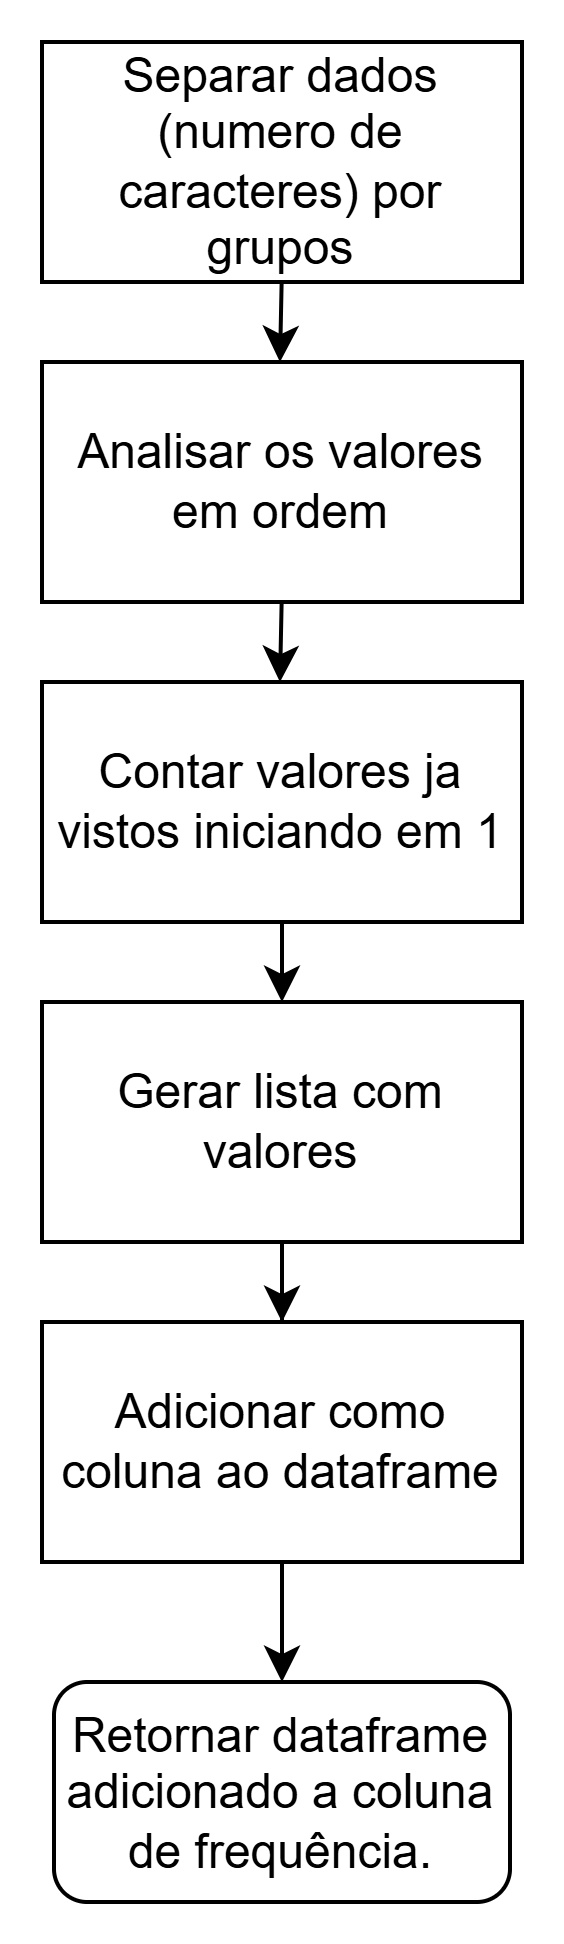

## 06 – Escreva o programa em Python:

In [6]:
genes0607["freq_ordem"] = (
    genes0607.groupby("numero de caracteres").cumcount() + 1
)
genes0607

,Unnamed: 0,numero de caracteres,2 primeiros caracteres,quantos 'a' existem,presença de 'hu',freq_ordem
0,srs12b,6,sr,0,False,1
1,sag1,4,sa,1,False,1
2,gra1,4,gr,1,False,2
3,tuba1,5,tu,1,False,1
4,sag3,4,sa,1,False,3


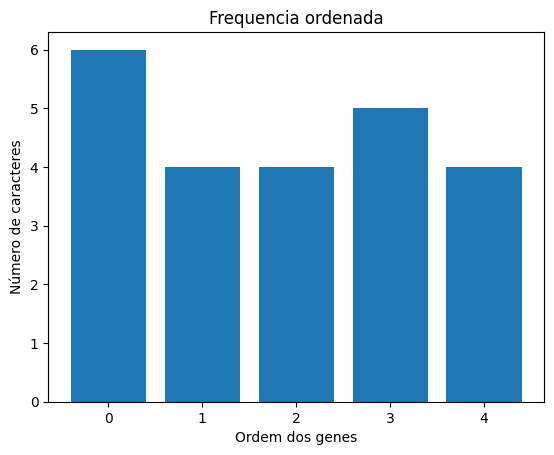

In [7]:
import matplotlib.pyplot as plt

plt.bar(range(len(genes0607)), genes0607["numero de caracteres"])

plt.xlabel("Ordem dos genes")
plt.ylabel("Número de caracteres")
plt.title("Frequencia ordenada")

plt.show()

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [8]:
genes = genes0607.iloc[:, [0, 1, 5]]
genes = genes.rename(columns={
    "Unnamed: 0": "gene",
    "numero de caracteres": "num_caracteres"
})
genes["amostra"] = "Amostra 1"
genes

,gene,num_caracteres,freq_ordem,amostra
0,srs12b,6,1,Amostra 1
1,sag1,4,1,Amostra 1
2,gra1,4,2,Amostra 1
3,tuba1,5,1,Amostra 1
4,sag3,4,3,Amostra 1


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [9]:
import numpy as np
amostra2 = np.random.randint(1, 10, 5)
amostra2

array([2, 6, 9, 8, 3], dtype=int32)

In [10]:
df2 = pd.DataFrame({"num_caracteres": amostra2})
df2["freq_ordem"] = (
    df2.groupby("num_caracteres").cumcount() + 1
)
df2

,num_caracteres,freq_ordem
0,2,1
1,6,1
2,9,1
3,8,1
4,3,1


In [11]:
df2["amostra"] = "Amostra 2"

In [12]:
df = pd.concat([genes, df2], ignore_index=True)
df

,gene,num_caracteres,freq_ordem,amostra
0,srs12b,6,1,Amostra 1
1,sag1,4,1,Amostra 1
2,gra1,4,2,Amostra 1
3,tuba1,5,1,Amostra 1
4,sag3,4,3,Amostra 1
5,NaN,2,1,Amostra 2
6,NaN,6,1,Amostra 2
7,NaN,9,1,Amostra 2
8,NaN,8,1,Amostra 2
9,NaN,3,1,Amostra 2


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [13]:
novas_amostras = []

for i in range(3, 7):  # 3, 4, 5, 6
    amostra = np.random.randint(1, 10, 5)

    df_temp = pd.DataFrame({"num_caracteres": amostra})

    df_temp["frequencia"] = df_temp.groupby("num_caracteres").cumcount() + 1 
    
    df_temp["amostra"] = f"Amostra {i}"

    novas_amostras.append(df_temp)

In [14]:
novas_amostras

[   num_caracteres  frequencia    amostra
 0               5           1  Amostra 3
 1               3           1  Amostra 3
 2               1           1  Amostra 3
 3               6           1  Amostra 3
 4               2           1  Amostra 3,
    num_caracteres  frequencia    amostra
 0               9           1  Amostra 4
 1               7           1  Amostra 4
 2               5           1  Amostra 4
 3               1           1  Amostra 4
 4               2           1  Amostra 4,
    num_caracteres  frequencia    amostra
 0               4           1  Amostra 5
 1               4           2  Amostra 5
 2               5           1  Amostra 5
 3               5           2  Amostra 5
 4               3           1  Amostra 5,
    num_caracteres  frequencia    amostra
 0               5           1  Amostra 6
 1               7           1  Amostra 6
 2               2           1  Amostra 6
 3               1           1  Amostra 6
 4               6           1 

In [15]:
df_final = pd.concat([df] + novas_amostras, ignore_index=True)
df_final

,gene,num_caracteres,freq_ordem,amostra,frequencia
0,srs12b,6,1.0,Amostra 1,NaN
1,sag1,4,1.0,Amostra 1,NaN
2,gra1,4,2.0,Amostra 1,NaN
3,tuba1,5,1.0,Amostra 1,NaN
4,sag3,4,3.0,Amostra 1,NaN
5,NaN,2,1.0,Amostra 2,NaN
6,NaN,6,1.0,Amostra 2,NaN
7,NaN,9,1.0,Amostra 2,NaN
8,NaN,8,1.0,Amostra 2,NaN
9,NaN,3,1.0,Amostra 2,NaN


## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

In [20]:
df_replicas = pd.concat([
    pd.DataFrame({"num_caracteres": np.random.randint(1, 10, 5)}).assign(
        frequencia=lambda x: x.groupby("num_caracteres").cumcount() + 1,
        amostra=f"Amostra {i}"
    )
    for i in range(7, 10)
], ignore_index=True)

In [21]:
df_total = pd.concat([df_final, df_replicas], ignore_index=True)

In [22]:
df_total

,gene,num_caracteres,freq_ordem,amostra,frequencia
0,srs12b,6,1.0,Amostra 1,NaN
1,sag1,4,1.0,Amostra 1,NaN
2,gra1,4,2.0,Amostra 1,NaN
3,tuba1,5,1.0,Amostra 1,NaN
4,sag3,4,3.0,Amostra 1,NaN
5,NaN,2,1.0,Amostra 2,NaN
6,NaN,6,1.0,Amostra 2,NaN
7,NaN,9,1.0,Amostra 2,NaN
8,NaN,8,1.0,Amostra 2,NaN
9,NaN,3,1.0,Amostra 2,NaN


In [23]:
freq_plot = (
    df_total
    .groupby(["amostra", "num_caracteres"])
    .size()
    .reset_index(name="frequencia")
)

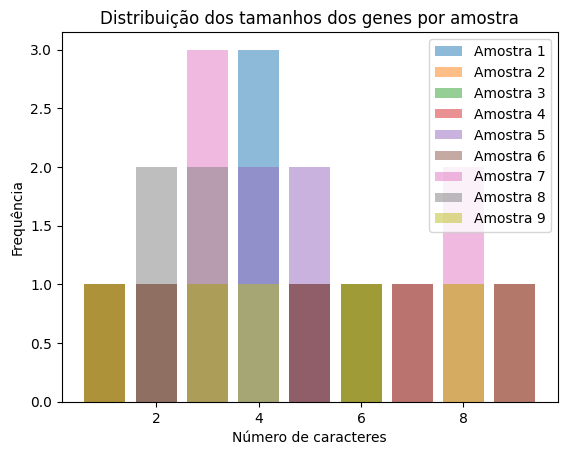

In [24]:
import matplotlib.pyplot as plt

for amostra in freq_plot["amostra"].unique():
    dados = freq_plot[freq_plot["amostra"] == amostra]
    plt.bar(
        dados["num_caracteres"],
        dados["frequencia"],
        alpha=0.5,
        label=amostra
    )

plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.title("Distribuição dos tamanhos dos genes por amostra")
plt.legend()
plt.show()